# 2025 Semester 2 - Computer Vision Main Project

Team Members: Guangheng (Jack) Tong  1129548, Nikolaos Fouras 912027

In [ ]:
###############################################################################

# Part 1 - Read in the data, resize the images and print out some sample images

###############################################################################

# Import packages
import pandas as pd
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Constants
MAIN_FOLDER = "Nutrition5K"
TEST_FOLDER = "/test"
TRAIN_FOLDER = "/train"
CSV_FILE_TRAINING = MAIN_FOLDER + "/nutrition5k_train.csv"
U_INT_8_MAX = 255.0
U_INT_16_MAX = 65535.0

COLOUR_IMAGE_FOLDER = "/color"
DEPTH_COLOUR_FOLDER = "/depth_color"
DEPTH_RAW_FOLDER = "/depth_raw"

COLOUR_IMG = "/rgb"
DEPTH_COLOUR = "/depth_color"
DEPTH_RAW = "/depth_raw"

IMG_DIRECTORY = "/dish_"
FILE_EXTENSION = ".png"

# ID ranges
MAX_TRAIN_IMG = 3301
MAX_TEST_IMG = 3490 # Last test image
NUM_ZEROS = 4

# Preview and plotting
NUM_SAMPLE_IMAGES = 3
HIST_BINS = 16

# Progress printing
TRAINING_IMAGE_COUNTER = 250
TEST_IMAGE_COUNTER = 50

# Resize
RESIZED_IMG_WIDTH = 128
RESIZED_IMG_HEIGHT = 96

# Known broken raw-depth file by numeric ID
BROKEN_DEPTH_FILE = 2368

# Labels
ORIGINAL_IMG = "original_image"

# Storage
training_colour_images = []   # list of (H,W,3) uint8, BGR
training_depth_colour = []    # list of (H,W,3) uint8, BGR (optional)
training_depth_raw = []       # list of (H,W,1) float32 in [0,1]

test_colour_images = []
test_depth_colour = []
test_depth_raw = []

###############################################################################

# Choose image types

COLOUR_IMAGE = 0
DEPTH_MAP = 1          # raw depth
DEPTH_MAP_COLOUR = 2   # colorized depth

selected_image_types = [COLOUR_IMAGE, DEPTH_MAP]  # RGB + raw depth
selected_image_types = list(set(selected_image_types))
assert len(selected_image_types) > 0
num_img_types_selected = len(selected_image_types)

###############################################################################

# Read Training images


# For each image
for image_id in range(0, MAX_TRAIN_IMG):

    # Check if it is the invalid file
    if image_id == BROKEN_DEPTH_FILE:
        continue

    # RGB
    if COLOUR_IMAGE in selected_image_types:

        # Get filepath for current image
        p_rgb = (MAIN_FOLDER + TRAIN_FOLDER + COLOUR_IMAGE_FOLDER +
                 IMG_DIRECTORY + str(image_id).zfill(NUM_ZEROS) + COLOUR_IMG + FILE_EXTENSION)
        
        # Read in standard 3 channel rgb        
        rgb = cv2.imread(p_rgb, cv2.IMREAD_COLOR)
        
        # Extra check that file is read in properly
        if rgb is None:
            raise FileNotFoundError(p_rgb)
   
        # Resize the image
        rgb = cv2.resize(rgb, (RESIZED_IMG_WIDTH, RESIZED_IMG_HEIGHT), interpolation=cv2.INTER_AREA)
        training_colour_images.append(rgb)

    # Colorized depth map (optional)
    if DEPTH_MAP_COLOUR in selected_image_types:
        
        # Get filepath for current image
        p_dcol = (MAIN_FOLDER + TRAIN_FOLDER + DEPTH_COLOUR_FOLDER +
                  IMG_DIRECTORY + str(image_id).zfill(NUM_ZEROS) + DEPTH_COLOUR + FILE_EXTENSION)
 
        # Read data in
        dcol = cv2.imread(p_dcol, cv2.IMREAD_COLOR)

        # Check that file is not empty
        if dcol is None:
            raise FileNotFoundError(p_dcol)

        # Resize image
        dcol = cv2.resize(dcol, (RESIZED_IMG_WIDTH, RESIZED_IMG_HEIGHT), interpolation=cv2.INTER_AREA)
        training_depth_colour.append(dcol)

    # For raw depth map
    if DEPTH_MAP in selected_image_types:

        # Get filepath for raw depth image
        p_draw = (MAIN_FOLDER + TRAIN_FOLDER + DEPTH_RAW_FOLDER +
                  IMG_DIRECTORY + str(image_id).zfill(NUM_ZEROS) + DEPTH_RAW + FILE_EXTENSION)

        # Read in raw depth map
        draw = cv2.imread(p_draw, cv2.IMREAD_UNCHANGED)

        # Ensure file is not empty 
        if draw is None:
            raise FileNotFoundError(p_draw)
        
        # Resize raw depth map
        draw = cv2.resize(draw, (RESIZED_IMG_WIDTH, RESIZED_IMG_HEIGHT), interpolation=cv2.INTER_NEAREST)

        # Given issues with raw depth input - perform check for type
        if draw.dtype == np.uint16:
            # Ensure proper uint16 format
            depth_f = draw.astype(np.float32) / U_INT_16_MAX
        else:
            # Ensure proper uint8 format
            depth_f = draw.astype(np.float32) / U_INT_8_MAX
        if depth_f.ndim == 2:
            depth_f = depth_f[..., None]
        else:
            depth_f = depth_f[..., :1]

        # Append to our array
        training_depth_raw.append(depth_f)

    # Print out progress message
    if image_id % TRAINING_IMAGE_COUNTER == 0:
        print("Processed training image number:", image_id)

print("All training images read in:", MAX_TRAIN_IMG, "candidates processed (broken ID skipped where applicable)")

###############################################################################

# Read in test images

# For each test image
for image_id in range(MAX_TRAIN_IMG, MAX_TEST_IMG):

    # RGB
    if COLOUR_IMAGE in selected_image_types:

        # Get filepath for image and read it in
        p_rgb = (MAIN_FOLDER + TEST_FOLDER + COLOUR_IMAGE_FOLDER +
                 IMG_DIRECTORY + str(image_id).zfill(NUM_ZEROS) + COLOUR_IMG + FILE_EXTENSION)
        rgb = cv2.imread(p_rgb, cv2.IMREAD_COLOR)

        # Check for invalid file (is empty)        
        if rgb is None:
            raise FileNotFoundError(p_rgb)
        
        # Resize image and add to array
        rgb = cv2.resize(rgb, (RESIZED_IMG_WIDTH, RESIZED_IMG_HEIGHT), interpolation=cv2.INTER_AREA)
        test_colour_images.append(rgb)

    # Colorized depth (optional)
    if DEPTH_MAP_COLOUR in selected_image_types:

        # Retrieve the filepath
        p_dcol = (MAIN_FOLDER + TEST_FOLDER + DEPTH_COLOUR_FOLDER +
                  IMG_DIRECTORY + str(image_id).zfill(NUM_ZEROS) + DEPTH_COLOUR + FILE_EXTENSION)
        
        # Read in the image
        dcol = cv2.imread(p_dcol, cv2.IMREAD_COLOR)
        if dcol is None:
            raise FileNotFoundError(p_dcol)

        # Resize the image and addd it to the array
        dcol = cv2.resize(dcol, (RESIZED_IMG_WIDTH, RESIZED_IMG_HEIGHT), interpolation=cv2.INTER_AREA)
        test_depth_colour.append(dcol)

    # Raw depth image (single channel)
    if DEPTH_MAP in selected_image_types:

        # Get filepath, read in image
        p_draw = (MAIN_FOLDER + TEST_FOLDER + DEPTH_RAW_FOLDER +
                  IMG_DIRECTORY + str(image_id).zfill(NUM_ZEROS) + DEPTH_RAW + FILE_EXTENSION)
        draw = cv2.imread(p_draw, cv2.IMREAD_UNCHANGED)

        # Check for invalid file
        if draw is None:
            raise FileNotFoundError(p_draw)

        # Resize the image
        draw = cv2.resize(draw, (RESIZED_IMG_WIDTH, RESIZED_IMG_HEIGHT), interpolation=cv2.INTER_NEAREST)
        
        # Handle invalid depth input
        if draw.dtype == np.uint16:
            depth_f = draw.astype(np.float32) / U_INT_16_MAX
        else:
            depth_f = draw.astype(np.float32) / U_INT_8_MAX
        if depth_f.ndim == 2:
            depth_f = depth_f[..., None]
        else:
            depth_f = depth_f[..., :1]

        # Append the image to the array
        test_depth_raw.append(depth_f)

    # Print out progress msg
    if image_id % TEST_IMAGE_COUNTER == 0:
        print("Processed test image number:", image_id)

print("All test images processed:", MAX_TEST_IMG - MAX_TRAIN_IMG, "images")

###############################################################################

# Preview select image samples


# Randomly select images
rand_index = [random.randint(0, max(0, len(training_colour_images) - 1)) for _ in range(NUM_SAMPLE_IMAGES)]
samples = []

# Print them out
for idx in rand_index:
    
    # Colour image
    if COLOUR_IMAGE in selected_image_types:
        samples.append(training_colour_images[idx])
    
    # Depth map
    if DEPTH_MAP in selected_image_types:
        # depth is float32 [0,1], convert to uint8 for display
        d8 = (training_depth_raw[idx].squeeze(-1) * 255.0).clip(0, 255).astype(np.uint8)
        d8 = cv2.cvtColor(d8, cv2.COLOR_GRAY2BGR)
        samples.append(d8)
    
    # Colour map
    if DEPTH_MAP_COLOUR in selected_image_types:
        samples.append(training_depth_colour[idx])

for i, img in enumerate(samples, 1):
    plt.subplot(NUM_SAMPLE_IMAGES, num_img_types_selected, i)
    plt.axis('off')
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

###############################################################################

# Data stored in arrays


training_colour_images_original = training_colour_images.copy()
training_depth_colour_original = training_depth_colour.copy()   
training_depth_raw_original = training_depth_raw.copy()

test_colour_images_original = test_colour_images.copy()
test_depth_colour_original = test_depth_colour.copy()
test_depth_raw_original = test_depth_raw.copy()


FileNotFoundError: Nutrition5K/train/color/dish_0000/rgb.png

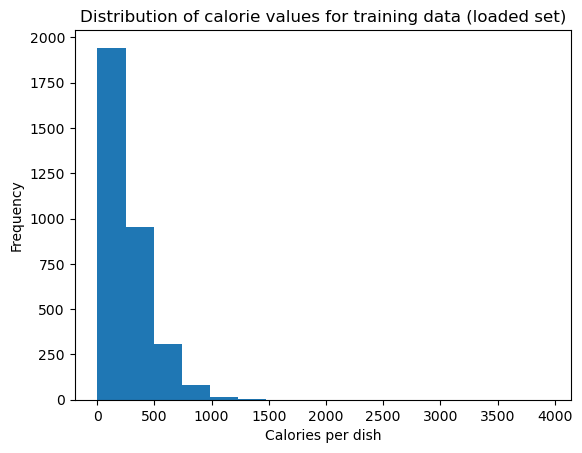

Summary statistics for our training metadata (loaded set)
          ID       Value
0  dish_0000  221.167068
1  dish_0001  140.980011
2  dish_0002  274.335999
3  dish_0003  589.501648
4  dish_0004  258.599670
             Value
count  3300.000000
mean    237.298713
std     221.319200
min       0.000000
25%      60.839996
50%     186.821724
75%     359.282753
max    3943.325195


In [ ]:
###############################################################################

# Part 2 - Print out some summary statistics

###############################################################################

# Constants
VALUE_LIST = 0
ID_LIST = 1
TRANSFORM_LIST = 2

# Read CSV
training_metadata = pd.read_csv(CSV_FILE_TRAINING)
assert {"ID", "Value"}.issubset(training_metadata.columns), "CSV must contain ID and Value."

# Set of dishes from part 1
loaded_ids = [f"dish_{i:04d}" for i in range(0, MAX_TRAIN_IMG) if i != BROKEN_DEPTH_FILE]

# Filter metadata to loaded IDs and keep the same order as loaded_ids
id2val = dict(zip(training_metadata["ID"], training_metadata["Value"]))
missing = [i for i in loaded_ids if i not in id2val]
assert len(missing) == 0, f"IDs missing from CSV: {missing[:5]}"

values_list = [float(id2val[i]) for i in loaded_ids]
id_list = loaded_ids.copy()

# Extra check that files were read in properly
n_imgs = len(training_colour_images)
assert n_imgs == len(id_list) == len(values_list), (
    f"Counts mismatch: images={n_imgs}, ids={len(id_list)}, values={len(values_list)}"
)

# Further check that we have read in depth maps if selected
if DEPTH_MAP in selected_image_types:
    assert len(training_depth_raw) == n_imgs, "RAW depth/image count mismatch."
if DEPTH_MAP_COLOUR in selected_image_types:
    assert len(training_depth_colour) == n_imgs, "Colorized depth/image count mismatch."

# Generate histogram and summary statistics
filtered_df = pd.DataFrame({"ID": id_list, "Value": values_list})

plt.figure()
plt.hist(filtered_df["Value"], HIST_BINS)
plt.xlabel("Calories per dish")
plt.ylabel("Frequency")
plt.title("Distribution of calorie values for training data (loaded set)")
plt.show()

print("Summary statistics for our training metadata (loaded set)")
print(filtered_df.head())
print(filtered_df.describe())

# Track transforms per image (i.e. due to augmentations)
transformations_list = [ORIGINAL_IMG] * n_imgs

orig_metadata = [values_list.copy(), id_list.copy(), transformations_list.copy()]


In [ ]:
###############################################################################

# Part 3 - Perform preprocessing and augmentation steps

###############################################################################

# Import packages
import numpy as np
import cv2 as cv

# Get arrays of image data
training_colour_images = training_colour_images_original.copy()
training_depth_raw     = training_depth_raw_original.copy()
training_depth_colour  = training_depth_colour_original.copy()

test_colour_images = test_colour_images_original.copy()
test_depth_raw     = test_depth_raw_original.copy()
test_depth_colour  = test_depth_colour_original.copy()

# Use these for DataFrame to store metadata
values_list        = orig_metadata[VALUE_LIST].copy()
id_list            = orig_metadata[ID_LIST].copy()
transformations_list = orig_metadata[TRANSFORM_LIST].copy()

# Settings to toggle
DO_FLIP = True
DO_BC   = False       # brightness/contrast on color only
DO_GAMMA = False      # default off (can enable)

# If image rotation has been selected
if DO_FLIP:

    # Constants which represent the flip types
    HORIZONTAL_FLIP = 1
    VERTICAL_FLIP   = 0
    BOTH_FLIP       = -1

    # Type of flips to perform
    flip_selection = [VERTICAL_FLIP, HORIZONTAL_FLIP, BOTH_FLIP] # Add/remove flip types

    # Get length of our array
    L0 = len(training_colour_images) if COLOUR_IMAGE in selected_image_types else \
         len(training_depth_raw)     if DEPTH_MAP in selected_image_types      else \
         len(training_depth_colour)
    
    # Iterate through all images
    for i in range(L0):

        # For each flip type chosen
        for f in flip_selection:

            # Flip colour image
            if COLOUR_IMAGE in selected_image_types:
                training_colour_images.append(cv.flip(training_colour_images[i], f))
    
            # Flip depth map
            if DEPTH_MAP in selected_image_types:
                training_depth_raw.append(cv.flip(training_depth_raw[i], f))

            # Flip depth map colour
            if DEPTH_MAP_COLOUR in selected_image_types:
                training_depth_colour.append(cv.flip(training_depth_colour[i], f))

            values_list.append(values_list[i])
            id_list.append(id_list[i])
            transformations_list.append(f"flip_{f}")
    
    # Print message
    print("Completed flipping. Total images:", len(training_colour_images) if COLOUR_IMAGE in selected_image_types else L0)
else:
    print("Skipped flipping")

###############################################################################

# Brightness/contrast adjustment

# If brightness/colour adjustment has been selected
if DO_BC and COLOUR_IMAGE in selected_image_types:

    ALPHAS = [1.1]  # Contrast
    BETAS  = [10]   # brightness
    
    # Set default brightness (alpha) and contrast (beta) values
    DEFAULT_A, DEFAULT_B = 1.0, 0

    # Append default values (if no ohter values were selected)    
    if DEFAULT_A not in ALPHAS: ALPHAS.append(DEFAULT_A)
    if DEFAULT_B not in BETAS:  BETAS.append(DEFAULT_B)

    L1 = len(training_colour_images)  # snapshot
    
    # For each colour image
    for i in range(L1):

        # Get the image
        img = training_colour_images[i]
        
        # For each brightness and contrast value selected
        for a in ALPHAS:
            for b in BETAS:

                # Properly handle default value
                if a == DEFAULT_A and b == DEFAULT_B: 
                    continue

                # Apply brightness/contrast adjustment
                adj = cv.convertScaleAbs(img, alpha=a, beta=b)
                training_colour_images.append(adj)

                # Handle depth maps (do not transform them)
                if DEPTH_MAP in selected_image_types:
                    training_depth_raw.append(training_depth_raw[i])
                if DEPTH_MAP_COLOUR in selected_image_types:
                    training_depth_colour.append(training_depth_colour[i])

                # Append updated images to array
                values_list.append(values_list[i])
                id_list.append(id_list[i])
                transformations_list.append(f"bc_a{a}_b{b}")

    # Print message
    print("Completed brightness/contrast. Total images:", len(training_colour_images))
else:
    print("Skipped brightness/contrast")

###############################################################################

# Gamma correction

if DO_GAMMA and COLOUR_IMAGE in selected_image_types:
    GAMMAS = [0.9]  # mild; add more if needed, e.g. [0.8, 1.2]
    
    MAX_PIXEL = 255.0
    NUM = 256
    
    L2 = len(training_colour_images)
    
    # For gamma values selected
    for g in GAMMAS:

        # build LUT once
        lut = np.empty((1, NUM), np.uint8)

        for pv in range(NUM):
            lut[0, pv] = np.clip(pow(pv / MAX_PIXEL, g) * MAX_PIXEL, 0, MAX_PIXEL)

        for i in range(L2):

            # Apply gamma transformation
            gamma_img = cv.LUT(training_colour_images[i], lut)
            training_colour_images.append(gamma_img)

            # Do not apply transformation to depth values
            if DEPTH_MAP in selected_image_types:
                training_depth_raw.append(training_depth_raw[i])
            if DEPTH_MAP_COLOUR in selected_image_types:
                training_depth_colour.append(training_depth_colour[i])

            # Append updated images
            values_list.append(values_list[i])
            id_list.append(id_list[i])
            transformations_list.append(f"gamma_{g}")
    
    # Gamma correction complete 
    print("Gamma correction - Complete!")
else:
    print("Skipped Gamma correction")

# Print message
print("Data augmentation - Complete!")
print("Total images:", len(training_colour_images) if COLOUR_IMAGE in selected_image_types else len(training_depth_raw))


Completed flipping. Total images: 13200
Skipped brightness/contrast
Skipped Gamma correction
Data augmentation - Complete!
Total images: 13200


In [ ]:
###############################################################################

# Part 4 - merge data into images and shuffle

###############################################################################

# Import packages
import numpy as np
CHANNEL_AXIS = -1


def ensure_3d(a):
    """
    Ensure that we are operating in 3D
    """
    return a[..., None] if a.ndim == 2 else a

def to_f32(a):
    return a.astype(np.float32, copy=False)

# Further check to verify all data is read in properly
if COLOUR_IMAGE in selected_image_types and DEPTH_MAP in selected_image_types:
    assert len(training_colour_images) == len(training_depth_raw), "len mismatch RGB vs RAW depth"

# Merge different image modalities
training_images_final = []
Ltr = len(training_colour_images) if COLOUR_IMAGE in selected_image_types else len(training_depth_raw)


# For each image
for i in range(Ltr):
    parts = []
    
    # Handle colour images
    if COLOUR_IMAGE in selected_image_types:
        rgb = ensure_3d(training_colour_images[i])         # (H,W,3) uint8 (BGR)
        parts.append(to_f32(rgb))                          # keep 0..255 for now
    
    # Handle depth map
    if DEPTH_MAP in selected_image_types:
        d = ensure_3d(training_depth_raw[i])               # (H,W,1) float32 in [0,1]
        parts.append(to_f32(d))
    
    # Handle depth map colour
    if DEPTH_MAP_COLOUR in selected_image_types:
        dc = ensure_3d(training_depth_colour[i])           
        parts.append(to_f32(dc))
    
    # Same H,W
    hws = {(p.shape[0], p.shape[1]) for p in parts}
    assert len(hws) == 1, f"Shape mismatch at {i}: {[p.shape for p in parts]}"
    merged = np.concatenate(parts, axis=CHANNEL_AXIS)      # e.g., (H,W,4)
    training_images_final.append(merged)

# Print message
print("Have selected all required train images - qty:", len(training_images_final))
print("Example merged train shape:", training_images_final[0].shape, "dtype:", training_images_final[0].dtype)

#############################################################################

# Shuffle images

idx = list(range(len(training_images_final)))
random.shuffle(idx)

training_images_final = [training_images_final[i] for i in idx]
values_list          = [values_list[i] for i in idx]
id_list              = [id_list[i] for i in idx]
transformations_list = [transformations_list[i] for i in idx]

# Prepare a dataframe
training_data_df = pd.DataFrame({
    "ID": id_list,
    "Value": values_list,
    "Transformation_Type": transformations_list
})
print("Images shuffled!")

# Merge test data
test_images_final = []
Lte = len(test_colour_images) if COLOUR_IMAGE in selected_image_types else len(test_depth_raw)

# Current image
for image_curr in range(Lte):
    parts_t = []
    
    # Colour image
    if COLOUR_IMAGE in selected_image_types:
        parts_t.append(to_f32(ensure_3d(test_colour_images[image_curr])))
    
    # Standard depth map
    if DEPTH_MAP in selected_image_types:
        parts_t.append(to_f32(ensure_3d(test_depth_raw[image_curr])))
    
    # For colour depth map
    if DEPTH_MAP_COLOUR in selected_image_types:
        parts_t.append(to_f32(ensure_3d(test_depth_colour[image_curr])))
    hws = {(p.shape[0], p.shape[1]) for p in parts_t}
    
    # Further check that images have been properly handled
    assert len(hws) == 1, f"[test] Shape mismatch at {image_curr}: {[p.shape for p in parts_t]}"
    test_images_final.append(np.concatenate(parts_t, axis=CHANNEL_AXIS))

# Print success message
print("Preprocessing and merging complete!")
print("Example merged test shape:", test_images_final[0].shape, "dtype:", test_images_final[0].dtype)

Have selected all required train images - qty: 13200
Example merged train shape: (96, 128, 4) dtype: float32
Images shuffled!
Preprocessing and merging complete!
Example merged test shape: (96, 128, 4) dtype: float32


Outlier filter: threshold=1005.4 kcal | removing 18 dish IDs
Removed examples (first 10): ['dish_0052', 'dish_0230', 'dish_0272', 'dish_0763', 'dish_1085', 'dish_1440', 'dish_1536', 'dish_1759', 'dish_1932', 'dish_1934']
Train set: 13132 samples | HxW=96x128 | channels=4
Test set:  189 samples
Fold1 VAL calorie dist: n=661 mean=234.0 std=207.2 p90=521.0 p95=643.6 max=1003.9
Fold2 VAL calorie dist: n=657 mean=229.5 std=201.5 p90=513.3 p95=623.9 max=948.9
Fold3 VAL calorie dist: n=655 mean=230.4 std=201.8 p90=504.3 p95=605.0 max=951.9
Fold4 VAL calorie dist: n=655 mean=232.3 std=201.4 p90=524.2 p95=610.2 max=919.1
Fold5 VAL calorie dist: n=655 mean=233.0 std=201.8 p90=508.4 p95=602.1 max=991.0
Device: cuda

========== Fold 1/5 ==========
Train idx: 10488 | Val idx: 661 | Unique VAL dishes: 661
Fold 1 params: 485,146
Fold 1 | Epoch 01 | train MSE 92980.709 | val MSE 94445.536 | lr 0.00030 | 21.1s
Fold 1 | Epoch 02 | train MSE 85029.350 | val MSE 89514.003 | lr 0.00030 | 20.6s
Fold 1 | Epo

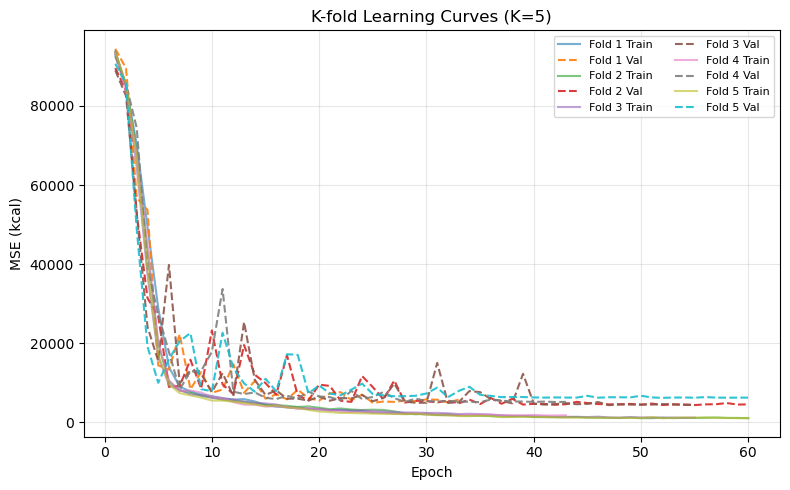


Best fold = 3 with val MSE 4357.493
Best fold loaders ready | train batches=55 | val batches=4


In [ ]:
################################################################################

# Part 5 - Train model and run evaluation 

#################################################################################

# Import packages
import os, time, math, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


# Determine whether we have a GPU available for PyTorch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
try: torch.set_float32_matmul_precision('high') # Set precision to ensure better processing
except: pass

# Get arrays from Part 4
X_full = np.asarray(training_images_final)
y_full = np.asarray(values_list, dtype=np.float32)
ids_full = np.asarray(id_list)
trans_full = np.asarray(transformations_list)
X_test = np.asarray(test_images_final)


X_full = X_full[..., :4]
X_test = X_test[..., :4]

# Prepare to exclude extreme outliers
EXCLUDE_OUTLIERS   = True
OUTLIER_BY         = "quantile"     # "abs" or "quantile"
OUTLIER_ABS_KCAL   = 1500.0
OUTLIER_QUANT      = 0.995
EXTRA_EXCLUDE_IDS  = {"dish_2368"}  # broken raw-depth

# ---- BGRD -> RGBD in [0,1] ----
def bgrd_to_rgbd01(arr):
    rgb = arr[..., :3][:, :, :, ::-1] / 255.0      # BGR->RGB
    d   = arr[..., 3:4]
    if float(d.max()) > 1.5: d = d / 255.0        
    return np.concatenate([rgb, d], axis=-1).astype(np.float32)

# Original mask
ORIGINAL_MASK = (trans_full == ORIGINAL_IMG)

# Get dish values
dish2cal_all = {}
for d, y, t in zip(ids_full, y_full, trans_full):
    if t == ORIGINAL_IMG and d not in dish2cal_all:
        dish2cal_all[d] = float(y)

# Remove outliers
if EXCLUDE_OUTLIERS:

    # Get dish ids and values
    dish_ids  = np.array(sorted(dish2cal_all.keys()))
    dish_vals = np.array([dish2cal_all[d] for d in dish_ids], dtype=np.float32)

    # Filter outliers depending on method
    if OUTLIER_BY == "quantile":
        thr = float(np.quantile(dish_vals, OUTLIER_QUANT))
    else:
        thr = OUTLIER_ABS_KCAL

    # Outliers
    bad_ids = set(d for d,v in dish2cal_all.items() if v > thr)
    bad_ids |= set(EXTRA_EXCLUDE_IDS)

    # Print message
    print(f"Outlier filter: threshold={thr:.1f} kcal | removing {len(bad_ids)} dish IDs")
    if len(bad_ids) > 0:
        print("Removed examples (first 10):", sorted(list(bad_ids))[:10])

    keep_mask   = ~np.isin(ids_full, list(bad_ids))
    X_full      = X_full[keep_mask]
    y_full      = y_full[keep_mask]
    ids_full    = ids_full[keep_mask]
    trans_full  = trans_full[keep_mask]
    ORIGINAL_MASK = ORIGINAL_MASK[keep_mask]

# Convert to proper colour channels after outlier removal
X_all = bgrd_to_rgbd01(X_full)
X_tst = bgrd_to_rgbd01(X_test)

# Get shape of image array
N, H, W, C = X_all.shape

# Print messages
print(f"Train set: {N} samples | HxW={H}x{W} | channels={C}")
print(f"Test set:  {X_tst.shape[0]} samples")

# Get stratified cross validation
K = 5 # Perform 5 partitions
rng = np.random.default_rng(SEED)

dish2cal = {}
for d, y, t in zip(ids_full, y_full, trans_full):
    if t == ORIGINAL_IMG and d not in dish2cal:
        dish2cal[d] = float(y)

unique_orig_ids = np.array(sorted(dish2cal.keys()))
vals = np.array([dish2cal[d] for d in unique_orig_ids], dtype=np.float32)
q = np.quantile(vals, [0.0, .2, .4, .6, .8, 1.0]); q[0] -= 1e-6
bins = np.digitize(vals, q)  # 1..5

bin_to_ids = {}
for d, b in zip(unique_orig_ids, bins):
    bin_to_ids.setdefault(b, []).append(d)

# Prepare to split partitions
fold_id_splits = [set() for _ in range(K)]
for b, id_list_b in bin_to_ids.items():
    id_list_b = np.array(id_list_b)
    rng.shuffle(id_list_b)
    parts = np.array_split(id_list_b, K)
    for k in range(K):
        fold_id_splits[k].update(parts[k].tolist())

# Get each fold
def describe_fold_ids(val_ids_set, name):
    vs = np.array([dish2cal[d] for d in sorted(val_ids_set)], dtype=np.float32)
    print(f"{name}: n={len(vs)} mean={vs.mean():.1f} std={vs.std():.1f} "
          f"p90={np.percentile(vs,90):.1f} p95={np.percentile(vs,95):.1f} max={vs.max():.1f}")

for i, ids_set in enumerate(fold_id_splits, 1):
    describe_fold_ids(ids_set, f"Fold{i} VAL calorie dist")


#################################################################################

# Dataset class for PyTorch

class RGBDNormDS(Dataset):
    """
    Gets data for PyTorch model
    """
    
    def __init__(self, X, y=None, mean=None, std=None):
        # Get data
        self.X, self.y = X, y
        # Compute mean
        self.mean = torch.from_numpy(mean) if mean is not None else None
        # Compute standard deviation
        self.std  = torch.from_numpy(std) if std is not None else None
    
    def __len__(self): return len(self.X)
    
    def __getitem__(self, i):
        x = torch.from_numpy(self.X[i].transpose(2, 0, 1))  # (4,H,W)
        if self.mean is not None:
            x = (x - self.mean[:,None,None]) / self.std[:,None,None]
        if self.y is None: return x
        return x, torch.tensor(self.y[i], dtype=torch.float32)


#######################################################################################

# Model 1 - Standard CNN architecture

class CalorieCNN4ch(nn.Module):
    """
    Class which runs standard CNN module
    """

    def __init__(self, in_ch: int, H: int, W: int):
        super().__init__()
        c = 32
        convolutional_filter_size = 3
        dense_layer_size = 128
        
        self.feat = nn.Sequential(
            
            # Convolutional layers
            nn.Conv2d(in_ch, c, convolutional_filter_size, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(c, c, convolutional_filter_size, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Second set of layers
            nn.Conv2d(c, 2 * c, convolutional_filter_size, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(2 * c, 2 * c, convolutional_filter_size, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Final set of convolutional layers
            nn.Conv2d(2 * c, 4 * c, convolutional_filter_size, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(4 * c, 4 * c, convolutional_filter_size, padding=1), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(4*c, 128), nn.ReLU(inplace=True), nn.Linear(dense_layer_size, 1))
    
    def forward(self, x):
        """
        Forward pass for standard CNN
        """
        return self.head(self.feat(x)).squeeze(1)

#######################################################################################

# Model 2 - CNN with residual connections

class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1):
        super().__init__()
        self.c = nn.Conv2d(in_ch, out_ch, k, s, p, bias=False)
        self.b = nn.BatchNorm2d(out_ch)
        self.a = nn.ReLU(inplace=True)
    def forward(self, x): return self.a(self.b(self.c(x)))

class SE(nn.Module):
    def __init__(self, ch, r=8):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(ch, ch//r, 1), nn.ReLU(inplace=True),
            nn.Conv2d(ch//r, ch, 1), nn.Sigmoid()
        )
    def forward(self, x): return x * self.fc(x)

class ResBlock(nn.Module):  
    """
    Class which creates the Residual connections
    """
    
    def __init__(self, ch, dil=1, se=True):
        super().__init__()
        p = dil
        self.f = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=p, dilation=dil, bias=False),
            nn.BatchNorm2d(ch), nn.ReLU(inplace=True),
            nn.Conv2d(ch, ch, 3, padding=p, dilation=dil, bias=False),
            nn.BatchNorm2d(ch)
        )
        self.se = SE(ch) if se else nn.Identity()
        self.a = nn.ReLU(inplace=True)

    def forward(self, x):
        """
        Perform a forward pass
        """
        y = self.f(x)
        y = self.se(y)
        return self.a(x + y)

class EnhancedResCNN4ch(nn.Module):
    """
    Enhanced CNN model with Residual Connections
    """

    def __init__(self, in_ch: int, H: int, W: int):
        super().__init__()
        c = 32

        self.stem = nn.Sequential(
            ConvBNAct(in_ch, c, 3, 1, 1),
            ConvBNAct(c, c, 3, 1, 1),
        )

        # Resnet blocks
        self.stage2 = nn.Sequential(
            nn.MaxPool2d(2),            # 1/2
            ConvBNAct(c, 2*c, 3, 1, 1),
            ResBlock(2*c), ResBlock(2*c)
        )
        self.stage3 = nn.Sequential(
            nn.MaxPool2d(2),            # 1/4
            ConvBNAct(2*c, 4*c, 3, 1, 1),
            ResBlock(4*c, dil=2), ResBlock(4*c, dil=2)
        )

        # Final dense section of model
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(4*c, 256), nn.ReLU(inplace=True), nn.Dropout(0.25),
            nn.Linear(256, 1)
        )


    def forward(self, x):
        """
        Forward Pass for Resnet-CNN model
        """
        x = self.stem(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.pool(x)
        return self.head(x).squeeze(1)

#######################################################################################

# Model 3 - Cross Modal Attention

class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1):
        super().__init__()
        self.c = nn.Conv2d(in_ch, out_ch, k, s, p, bias=False)
        self.b = nn.BatchNorm2d(out_ch)
        self.a = nn.ReLU(inplace=True)
    def forward(self, x): return self.a(self.b(self.c(x)))

class ResBlock(nn.Module):
    def __init__(self, ch, dil=1):
        super().__init__()
        self.f = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=dil, dilation=dil, bias=False),
            nn.BatchNorm2d(ch), nn.ReLU(inplace=True),
            nn.Conv2d(ch, ch, 3, padding=dil, dilation=dil, bias=False),
            nn.BatchNorm2d(ch),
        )
        self.a = nn.ReLU(inplace=True)
    def forward(self, x): return self.a(x + self.f(x))

class XMACModelC(nn.Module):
    """
    Cross-modal attention model
    """

    def __init__(self):
        super().__init__()
        
        c = 48 # Key Parameter we varied for hyperparameter tuning
        
        self.rgb1 = ConvBNAct(3, c)
        self.d1   = ConvBNAct(1, c // 2)
        self.rgb2 = nn.Sequential(ConvBNAct(c, c), nn.MaxPool2d(2))
        self.d2   = nn.Sequential(ConvBNAct(c // 2, c // 2), nn.MaxPool2d(2))
        self.att1 = nn.Sequential(nn.Conv2d(c // 2, c, 1), nn.Sigmoid())
        self.mix1 = ConvBNAct(c + c // 2, c)
        self.rgb3 = nn.Sequential(ResBlock(c), ConvBNAct(c, 2*c), nn.MaxPool2d(2))
        self.d3   = nn.Sequential(ResBlock(c // 2), ConvBNAct(c // 2, c), nn.MaxPool2d(2))
        self.att2 = nn.Sequential(nn.Conv2d(c, 2*c, 1), nn.Sigmoid())
        self.mix2 = ConvBNAct(2*c + c, 2*c)
        self.trunk = ResBlock(2*c, dil=2)
        self.pool  = nn.AdaptiveAvgPool2d(1)
        self.reg   = nn.Sequential(nn.Flatten(),
                                   nn.Linear(2*c, 256), nn.ReLU(inplace=True), nn.Dropout(0.3),
                                   nn.Linear(256, 1))
        self.aux   = nn.Conv2d(2*c, 1, 1)
    
    def forward(self, x):
        """
        Perform forward pass for the model
        """
        
        rgb, d = x[:, :3], x[:, 3:4]
        r1  = self.rgb1(rgb); de1 = self.d1(d)
        r2  = self.rgb2(r1);  de2 = self.d2(de1)
        r2  = r2 * (1 + self.att1(de2))
        f2  = self.mix1(torch.cat([r2, de2], dim=1))
        r3  = self.rgb3(f2);  de3 = self.d3(de2)
        r3  = r3 * (1 + self.att2(de3))
        f3  = self.mix2(torch.cat([r3, de3], dim=1))
        y_aux = self.aux(f3)
        z = self.trunk(f3); z = self.pool(z)
        y = self.reg(z).squeeze(1)
        return y, y_aux

####################################################################################

# Helper functions

def make_loaders_for_fold(train_idx, val_idx, batch=192):
    ch_mean = X_all[train_idx].mean(axis=(0,1,2)).astype(np.float32)
    ch_std  = X_all[train_idx].std(axis=(0,1,2)).astype(np.float32) + 1e-6
    train_ds = RGBDNormDS(X_all[train_idx], y_full[train_idx], ch_mean, ch_std)
    val_ds   = RGBDNormDS(X_all[val_idx],   y_full[val_idx],   ch_mean, ch_std)
    test_ds  = RGBDNormDS(X_tst,            None,              ch_mean, ch_std)
    pin = torch.cuda.is_available()
    tl = DataLoader(train_ds, batch_size=batch, shuffle=True,  num_workers=0, pin_memory=pin)
    vl = DataLoader(val_ds,   batch_size=batch, shuffle=False, num_workers=0, pin_memory=pin)
    zl = DataLoader(test_ds,  batch_size=batch, shuffle=False, num_workers=0, pin_memory=pin)
    return tl, vl, zl, ch_mean, ch_std

def run_epoch(model, loader, optimizer, crit_main, crit_aux, aux_lambda, training: bool):
    model.train(training)
    se, n = 0.0, 0
    for batch in loader:
        if training: xb, yb = batch
        else:
            with torch.no_grad(): xb, yb = batch
        xb = xb.to(device, non_blocking=True); yb = yb.to(device, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=(device.type=='cuda')):
                pred, aux = model(xb)                   # predict kcal directly
                loss = crit_main(pred, yb)              # MSE on kcal
                depth_t = F.interpolate(xb[:, 3:4], size=aux.shape[-2:], mode='bilinear', align_corners=False)
                loss = loss + aux_lambda * crit_aux(aux, depth_t)
            scaler.scale(loss).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            scaler.step(optimizer); scaler.update()
        else:
            with torch.no_grad():
                pred, _ = model(xb)

        se += torch.sum((pred - yb) ** 2).item()
        n  += yb.numel()
    return se / max(1,n)


# ---- K-fold training ----
BATCH = 192
EPOCHS = 60
AUX_LAMBDA = 0.1

fold_histories, fold_best_vals, fold_test_preds = [], [], []
fold_train_idxs, fold_val_idxs, fold_ckpts = [], [], []

# For each fold
for fold in range(1, K+1):
    val_ids_set = set(fold_id_splits[fold-1])
    # VAL = originals only for dishes in this fold (reuse ORIGINAL_MASK)
    val_idx = np.array([i for i,(d,o) in enumerate(zip(ids_full, ORIGINAL_MASK)) if (d in val_ids_set) and o], dtype=np.int64)
    # TRAIN = everything else (including augmentations not in current VAL dishes)
    train_idx = np.array([i for i,d in enumerate(ids_full) if d not in val_ids_set], dtype=np.int64)

    print(f"\n========== Fold {fold}/{K} ==========")
    print(f"Train idx: {len(train_idx)} | Val idx: {len(val_idx)} | Unique VAL dishes: {len(val_ids_set)}")

    train_loader, val_loader, test_loader, _cm, _cs = make_loaders_for_fold(train_idx, val_idx, batch=BATCH)

    #####
    
    # Select model here
    model = XMACModelC().to(device)
    
    #####
    
    print(f"Fold {fold} params: {sum(p.numel() for p in model.parameters()):,}")
    optimizer  = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3)
    crit_main  = nn.MSELoss()
    crit_aux   = nn.L1Loss()
    scaler     = torch.amp.GradScaler('cuda', enabled=(device.type=='cuda'))

    best_val = float('inf'); patience = 8; stale = 0
    hist_ep, hist_tr, hist_va = [], [], []
    ckpt_path = f"best_XMAC_fold{fold}.pt"
    if os.path.exists(ckpt_path): os.remove(ckpt_path)

    # For each epoch
    for epoch in range(1, EPOCHS+1):

        # Get current time
        t0 = time.time()
        tr_mse = run_epoch(model, train_loader, optimizer, crit_main, crit_aux, AUX_LAMBDA, training=True)
        with torch.no_grad():
            va_mse = run_epoch(model, val_loader, optimizer, crit_main, crit_aux, AUX_LAMBDA, training=False)
        scheduler.step(va_mse)
        dt = time.time() - t0

        # Current learning rate
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Fold {fold} | Epoch {epoch:02d} | train MSE {tr_mse:.3f} | val MSE {va_mse:.3f} | lr {lr_now:.5f} | {dt:.1f}s")
        hist_ep.append(epoch); hist_tr.append(tr_mse); hist_va.append(va_mse)

        # Determine if early stopping needs to occur
        if va_mse + 1e-9 < best_val:
            best_val = va_mse; stale = 0
            torch.save({'state_dict': model.state_dict()}, ckpt_path)
        else:
            stale += 1
            if stale >= patience:
                print(f"Fold {fold}: early stopping")
                break

    fold_histories.append({'epoch': hist_ep, 'tr': hist_tr, 'va': hist_va})
    fold_best_vals.append(best_val)
    fold_train_idxs.append(train_idx); fold_val_idxs.append(val_idx); fold_ckpts.append(ckpt_path)

    # Perform inference
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['state_dict']); model.eval()
    preds = []
    with torch.no_grad():
        for xb in test_loader:
            xb = xb.to(device, non_blocking=True)
            yhat, _ = model(xb)
            preds.extend(yhat.float().cpu().numpy().tolist())
    fold_test_preds.append(np.array(preds, dtype=np.float32))


# Generate test statistics to be used for the report
fold_test_preds = np.stack(fold_test_preds, axis=0)
ens_test = np.mean(fold_test_preds, axis=0)
test_data_predictions = [max(0.0, float(v)) for v in ens_test]
print(f"\nK-fold summary: best val MSEs per fold = {[f'{v:.3f}' for v in fold_best_vals]}")
print(f"Mean best val MSE = {np.mean(fold_best_vals):.3f}")
print(f"Generated {len(test_data_predictions)} test predictions (ensembled over {K} folds).")


# Generate loss curve (across the partitions)
plt.figure(figsize=(8,5))
for f, hist in enumerate(fold_histories, start=1):
    plt.plot(hist['epoch'], hist['tr'], alpha=0.6, label=f"Fold {f} Train")
    plt.plot(hist['epoch'], hist['va'], alpha=0.9, linestyle='--', label=f"Fold {f} Val")
plt.xlabel("Epoch"); plt.ylabel("MSE (kcal)"); plt.title(f"K-fold Learning Curves (K={K})")
plt.grid(True, alpha=0.3); plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig("learning_curve_mse_kfold.png", dpi=150)
plt.show()

best_fold = int(np.argmin(fold_best_vals))
print(f"\nBest fold = {best_fold+1} with val MSE {fold_best_vals[best_fold]:.3f}")
train_loader, val_loader, _test_loader, ch_mean, ch_std = make_loaders_for_fold(
    fold_train_idxs[best_fold], fold_val_idxs[best_fold], batch=BATCH
)
val_idx = fold_val_idxs[best_fold]

model = XMACModelC().to(device)
ckpt = torch.load(fold_ckpts[best_fold], map_location=device)
model.load_state_dict(ckpt['state_dict'])
model.eval()

# Sanity prints (optional)
print(f"Best fold loaders ready | train batches={len(train_loader)} | val batches={len(val_loader)}")

Train: MAE 18.695 | MSE 612.270 | RMSE 24.744 | MBE 2.616
Val: MAE 42.833 | MSE 4357.493 | RMSE 66.011 | MBE 2.627


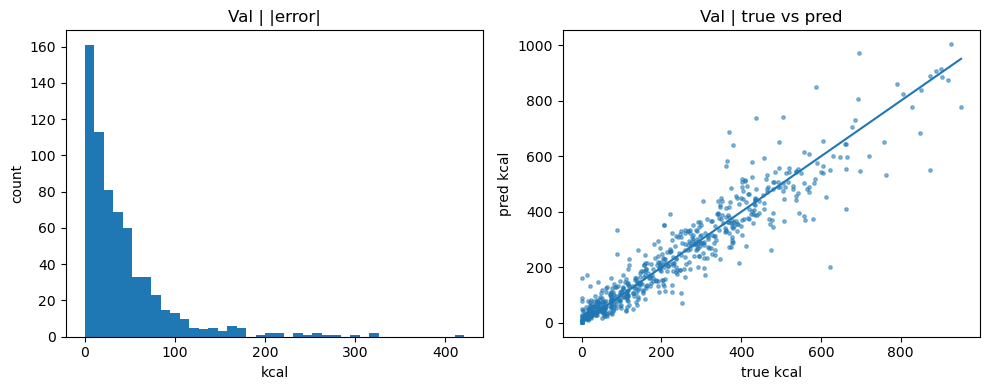


Top-10 most accurate (smallest |error|):
dish_0833 | y=55.9 pred=55.9 | |e|=0.0
dish_2163 | y=503.8 pred=503.8 | |e|=0.0
dish_0757 | y=284.7 pred=284.6 | |e|=0.1
dish_1520 | y=24.0 pred=23.8 | |e|=0.2
dish_1989 | y=116.7 pred=117.0 | |e|=0.3
dish_2131 | y=315.6 pred=315.3 | |e|=0.3
dish_1297 | y=74.4 pred=73.9 | |e|=0.5
dish_0670 | y=19.5 pred=20.1 | |e|=0.6
dish_0635 | y=142.7 pred=143.3 | |e|=0.6
dish_0262 | y=61.7 pred=61.1 | |e|=0.6

Top-10 least accurate (largest |error|):
dish_2751 | y=623.2 pred=202.3 | |e|=420.9
dish_0368 | y=875.0 pred=551.0 | |e|=324.0
dish_2854 | y=368.3 pred=686.6 | |e|=318.3
dish_2270 | y=437.1 pred=737.7 | |e|=300.6
dish_0728 | y=696.4 pred=972.1 | |e|=275.7
dish_3089 | y=587.7 pred=851.9 | |e|=264.1
dish_2770 | y=380.3 pred=642.3 | |e|=262.0
dish_2149 | y=663.9 pred=408.6 | |e|=255.3
dish_2660 | y=87.7 pred=334.2 | |e|=246.5
dish_0603 | y=504.4 pred=742.6 | |e|=238.2


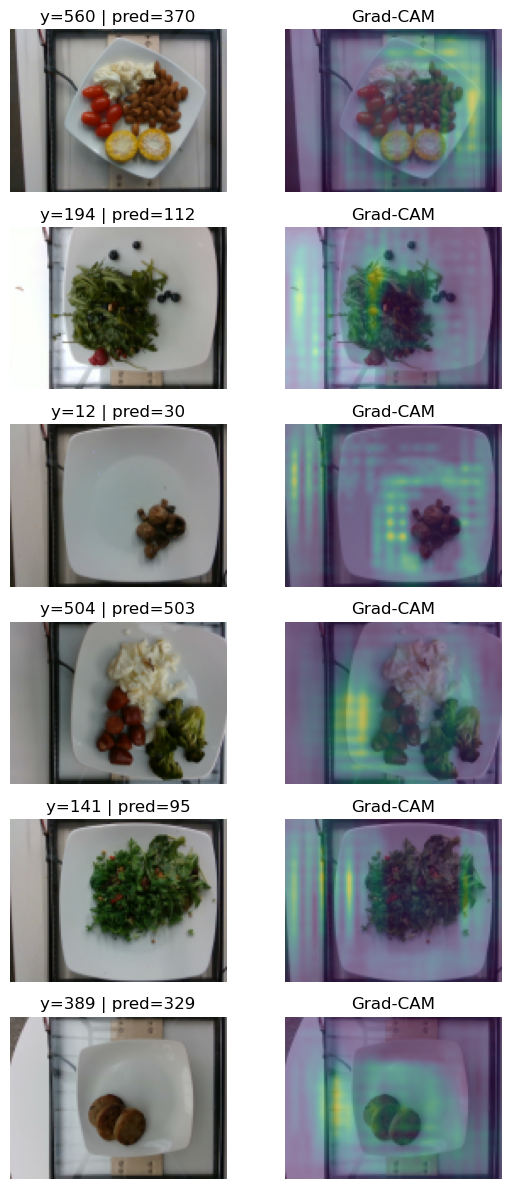


Test predictions ready: 189 items.


In [ ]:
##############################################################################

# Part 6 - Model Evaluation

##############################################################################

# Packages
import math, numpy as np, torch, matplotlib.pyplot as plt, cv2
import torch.nn.functional as F
import torch.nn as nn

# Require Part 5 to be run first
assert 'model' in globals() and 'train_loader' in globals() and 'val_loader' in globals(), \
    "Run Part 5 first to create model/train_loader/val_loader."
assert 'ch_mean' in globals() and 'ch_std' in globals(), "Missing ch_mean/ch_std from Part 5."
device = next(model.parameters()).device

# Helper functions
@torch.no_grad()
def run_inference(loader, model, device):
    """
    Function which completes inference
    """

    # Run model evaluation
    model.eval()
    preds, gts = [], []

    # For each validation instance
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        out = model(xb)
        yhat = out[0] if isinstance(out, tuple) else out
        
        # Get predicted value
        preds.append(yhat.float().cpu().numpy())
        gts.append(yb.float().cpu().numpy())
    
    # Get true and predicted values
    y_pred = np.concatenate(preds, axis=0)
    y_true = np.concatenate(gts, axis=0)

    return y_true, y_pred

def metrics(y_true, y_pred):
    err = y_pred - y_true
    mae = float(np.mean(np.abs(err)))
    mse = float(np.mean(err**2))
    rmse = math.sqrt(mse)
    mbe = float(np.mean(err))
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "MBE": mbe}

def summarize_split(name, y_true, y_pred):
    m = metrics(y_true, y_pred)
    print(f"{name}: MAE {m['MAE']:.3f} | MSE {m['MSE']:.3f} | RMSE {m['RMSE']:.3f} | MBE {m['MBE']:.3f}")
    return m

# Run evaluation
y_tr, yhat_tr = run_inference(train_loader, model, device)
y_va, yhat_va = run_inference(val_loader,   model, device)

m_tr = summarize_split("Train", y_tr, yhat_tr)
m_va = summarize_split("Val",   y_va, yhat_va)

# Generate error plots
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.hist(np.abs(yhat_va - y_va), bins=40); plt.title("Val | |error|"); plt.xlabel("kcal"); plt.ylabel("count")
plt.subplot(1,2,2); plt.scatter(y_va, yhat_va, s=6, alpha=0.5)
mn,mx = float(np.min(y_va)), float(np.max(y_va)); plt.plot([mn,mx],[mn,mx])
plt.title("Val | true vs pred"); plt.xlabel("true kcal"); plt.ylabel("pred kcal")
plt.tight_layout(); plt.show()

# Get best/worse dishes
val_ids_array = (np.asarray([ids_full[i] for i in val_idx])
                 if 'val_idx' in globals() and 'ids_full' in globals()
                 else np.array([f"val_{i}" for i in range(len(y_va))]))
abs_err = np.abs(yhat_va - y_va)
order = np.argsort(abs_err)

K = 10
print("\nTop-10 most accurate (smallest |error|):")
for i in order[:K]:
    print(f"{val_ids_array[i]} | y={y_va[i]:.1f} pred={yhat_va[i]:.1f} | |e|={abs_err[i]:.1f}")

print("\nTop-10 least accurate (largest |error|):")
for i in order[-K:][::-1]:
    print(f"{val_ids_array[i]} | y={y_va[i]:.1f} pred={yhat_va[i]:.1f} | |e|={abs_err[i]:.1f}")


# Grad-CAM on a few validation samples
class GradCAM:
    """
    GradCAM

    Perform analysis - allowing us to see where the model is looking
    """

    def __init__(self, model, target_module):
        """
        Initialises the GradCAM        
        """

        self.model = model
        self.fmap = None
        self.grad = None

        def fwd_hook(_, __, output): self.fmap = output.detach()
        def bwd_hook(_, grad_input, grad_output): self.grad = grad_output[0].detach()
        
        self.h1 = target_module.register_forward_hook(fwd_hook)
        self.h2 = target_module.register_full_backward_hook(bwd_hook)
    
    def __call__(self, x):
    
        self.model.zero_grad(set_to_none=True)
        out = self.model(x)
        y = out[0] if isinstance(out, tuple) else out
        y.sum().backward()  # gradients wrt sum of outputs
        w = torch.mean(self.grad, dim=(2,3), keepdim=True)
    
        # Complete grad-cam
        cam = torch.sum(w * self.fmap, dim=1, keepdim=True)
        cam = F.relu(cam)
        cam -= cam.amin(dim=(2,3), keepdim=True)
        cam /= (cam.amax(dim=(2,3), keepdim=True) + 1e-6)
        return cam
    
    def close(self):
        self.h1.remove(); self.h2.remove()

# pick a conv layer (2nd conv in trunk ResBlock is index 3)
target_layer = model.trunk.f[3] if hasattr(model, "trunk") else \
               next((m for m in reversed(list(model.modules())) if isinstance(m, nn.Conv2d)), None)
cam = GradCAM(model, target_layer)

# denorm utility (use best-fold mean/std from Part 5)
def denorm_rgb(x4c):
    # x4c: (4,H,W) tensor normalized; revert then take RGB in [0,1]
    mean = torch.as_tensor(ch_mean)[:, None, None].to(x4c.dtype)
    std  = torch.as_tensor(ch_std)[:, None, None].to(x4c.dtype)
    x = (x4c * std + mean).clamp(0, 1)
    rgb = x[:3].permute(1,2,0).cpu().numpy()
    return rgb

# visualize first few validation samples
to_show = min(6, len(val_loader.dataset))
fig, axes = plt.subplots(to_show, 2, figsize=(6, 2 * to_show))
model.eval()
for i in range(to_show):

    # Get the data
    x_i, y_i = val_loader.dataset[i]
    x_b = x_i.unsqueeze(0).to(device)

    # Validation
    with torch.no_grad():
        out = model(x_b)
        yhat_i = (out[0] if isinstance(out, tuple) else out)
    cam_map = cam(x_b).cpu().numpy()[0,0]  # (h,w)
    
    # Upsample CAM to input HxW
    H, W = x_i.shape[1], x_i.shape[2]
    cam_up = cv2.resize(cam_map, (W, H), interpolation=cv2.INTER_CUBIC)

    rgb = denorm_rgb(x_i)
    axes[i,0].imshow(rgb); axes[i,0].axis('off'); axes[i,0].set_title(f"y={float(y_i):.0f} | pred={float(yhat_i.item()):.0f}")
    axes[i,1].imshow(rgb); axes[i,1].imshow(cam_up, alpha=0.45); axes[i,1].axis('off'); axes[i,1].set_title("Grad-CAM")

cam.close()
plt.tight_layout(); plt.show()

# Keep test_data_predictions unchanged
if 'test_data_predictions' in globals():
    print(f"\nTest predictions ready: {len(test_data_predictions)} items.")
else:
    print("\nNote: test_data_predictions not found (run Part 5 to generate them).")


In [ ]:
###############################################################################

# Part 7  - Generate CSV for Kaggle competition

###############################################################################

# Import packages
import os
import pandas as pd

# Get input from earlier sections
# test_data_predictions : list[float]
# MAX_TRAIN_IMG, MAX_TEST_IMG, OFFSET, NUM_ZEROS, IMG_DIRECTORY

def make_kaggle_csv(preds, filename = "submission.csv"):
    """
    Function which generates CSV for KAGGLE
    """

    assert len(preds) == (MAX_TEST_IMG - MAX_TRAIN_IMG), (
        f"Predictions={len(preds)} but expected {MAX_TEST_IMG - MAX_TRAIN_IMG}"
    )

    # Strip any leading slash from '/dish_'
    id_prefix = IMG_DIRECTORY.lstrip('/')  # Remove it
    start = MAX_TRAIN_IMG

    ids = [f"{id_prefix}{str(start + i).zfill(NUM_ZEROS)}" for i in range(len(preds))]
    values = [float(max(0.0, p)) for p in preds]  # keep non-negative

    # Create the dataframe
    df = pd.DataFrame({"ID": ids, "Value": values}).sort_values("ID").reset_index(drop=True)

    # Ensure proper file suffix
    if not filename.lower().endswith(".csv"):
        filename = f"{filename}.csv"

    # Convert to CSV
    df.to_csv(filename, index=False)
    print(f"Saved {filename} with {len(df)} rows")
    print(df.head())

# Run
make_kaggle_csv(test_data_predictions, filename="COMP90086_Assignment_predictions")

Saved COMP90086_Assignment_predictions.csv with 189 rows
          ID       Value
0  dish_3301  987.697632
1  dish_3302   43.931725
2  dish_3303   21.209623
3  dish_3304  159.488129
4  dish_3305  543.840698
